In [7]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:

import sys
def noise_corrected(table, undirected = False, return_self_loops = False, calculate_p_value = False):
   sys.stderr.write("Calculating NC score...\n")
   table = table.copy()
   src_sum = table.groupby(by = "src").sum()[["nij"]]
   table = table.merge(src_sum, left_on = "src", right_index = True, suffixes = ("", "_src_sum"))
   trg_sum = table.groupby(by = "trg").sum()[["nij"]]
   table = table.merge(trg_sum, left_on = "trg", right_index = True, suffixes = ("", "_trg_sum"))
   table.rename(columns = {"nij_src_sum": "ni.", "nij_trg_sum": "n.j"}, inplace = True)
   table["n.."] = table["nij"].sum()
   table["mean_prior_probability"] = ((table["ni."] * table["n.j"]) / table["n.."]) * (1 / table["n.."])
   if calculate_p_value:
      table["score"] = binom.cdf(table["nij"], table["n.."], table["mean_prior_probability"])
      return table[["src", "trg", "nij", "score"]]
   table["kappa"] = table["n.."] / (table["ni."] * table["n.j"])
   table["score"] = ((table["kappa"] * table["nij"]) - 1) / ((table["kappa"] * table["nij"]) + 1)
   table["var_prior_probability"] = (1 / (table["n.."] ** 2)) * (table["ni."] * table["n.j"] * (table["n.."] - table["ni."]) * (table["n.."] - table["n.j"])) / ((table["n.."] ** 2) * ((table["n.."] - 1)))
   table["alpha_prior"] = (((table["mean_prior_probability"] ** 2) / table["var_prior_probability"]) * (1 - table["mean_prior_probability"])) - table["mean_prior_probability"]
   table["beta_prior"] = (table["mean_prior_probability"] / table["var_prior_probability"]) * (1 - (table["mean_prior_probability"] ** 2)) - (1 - table["mean_prior_probability"])
   table["alpha_post"] = table["alpha_prior"] + table["nij"]
   table["beta_post"] = table["n.."] - table["nij"] + table["beta_prior"]
   table["expected_pij"] = table["alpha_post"] / (table["alpha_post"] + table["beta_post"])
   table["variance_nij"] = table["expected_pij"] * (1 - table["expected_pij"]) * table["n.."]
   table["d"] = (1.0 / (table["ni."] * table["n.j"])) - (table["n.."] * ((table["ni."] + table["n.j"]) / ((table["ni."] * table["n.j"]) ** 2)))
   table["variance_cij"] = table["variance_nij"] * (((2 * (table["kappa"] + (table["nij"] * table["d"]))) / (((table["kappa"] * table["nij"]) + 1) ** 2)) ** 2) 
   table["sdev_cij"] = table["variance_cij"] ** .5
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table = table[table["src"] <= table["trg"]]
   return table[["src", "trg", "nij", "score", "sdev_cij"]]

In [9]:
airports = pd.read_csv("data/airports.csv")
routes = pd.read_csv("data/routes.csv")

In [10]:
# Replace missing continent for U.S. airports with "NA"
airports.loc[airports["iso_country"] == "US", "continent"] = airports.loc[airports["iso_country"] == "US", "continent"].fillna("NA")

# Drop airports missing essential info
airports = airports.dropna(subset=["id", "latitude_deg", "longitude_deg"])

# Clean route ID columns ('\\N' means missing)
routes["Source airport ID"] = routes["Source airport ID"].replace("\\N", pd.NA)
routes["Destination airport ID"] = routes["Destination airport ID"].replace("\\N", pd.NA)

# Drop missing IDs and convert to int
routes = routes.dropna(subset=["Source airport ID", "Destination airport ID"])
routes["Source airport ID"] = routes["Source airport ID"].astype(int)
routes["Destination airport ID"] = routes["Destination airport ID"].astype(int)
airports["id"] = airports["id"].astype(int)

In [11]:
nato_countries = [
    "US","CA","IS","NO","DK","NL","BE","LU","FR","DE","IT","PT",
    "UK","ES","GR","TR","PL","CZ","HU","SK","SI","HR","BG","RO",
    "EE","LV","LT","AL","ME","MK", "SE", "FI"
]

In [12]:
airports_nato = airports[airports["iso_country"].isin(nato_countries)]
print("NATO airports:", len(airports_nato))

# Keep only routes where BOTH airports are NATO members
routes_nato = routes[
    routes["Source airport ID"].isin(airports_nato["id"]) &
    routes["Destination airport ID"].isin(airports_nato["id"])
]
print("NATO routes:", len(routes_nato))

NATO airports: 44309
NATO routes: 32325


In [13]:
# Each row = one airline operating a route
# Group by source/destination to count how many flights per pair
route_weights = (
    routes_nato
    .groupby(["Source airport ID", "Destination airport ID"])
    .size()
    .reset_index(name="weight")
)

print("Unique weighted routes:", len(route_weights))
print("Average route weight:", route_weights["weight"].mean())

Unique weighted routes: 17170
Average route weight: 1.882644146767618


In [14]:
# 🔹 Directed graph: A → B is NOT the same as B → A
G = nx.DiGraph()

# Add NATO airports as nodes
for _, row in airports_nato.iterrows():
    G.add_node(
        row["id"],
        country=row["iso_country"],
        name=row["name"],
        lat=row["latitude_deg"],
        lon=row["longitude_deg"]
    )

# Add directed edges with weight (number of flights)
for _, row in route_weights.iterrows():
    G.add_edge(
        row["Source airport ID"],
        row["Destination airport ID"],
        weight=row["weight"]
    )

# Remove isolated nodes (airports with no routes in or out)
isolated_nodes = [n for n, d in G.degree() if d == 0]
print(f"Removing {len(isolated_nodes)} isolated airports")
G.remove_nodes_from(isolated_nodes)
print("Graph after removing isolated nodes: ", G)

largest_wcc = len(max(nx.weakly_connected_components(G), key=len))
largest_scc = len(max(nx.strongly_connected_components(G), key=len))
print("Largest weakly connected component size:", largest_wcc)
print("Largest weakly connected component size:", largest_scc)

Removing 42490 isolated airports
Graph after removing isolated nodes:  DiGraph with 1819 nodes and 17170 edges
Largest weakly connected component size: 1728
Largest weakly connected component size: 1695


compared to 44.000 airports and 32.000 routes.

taking into account direction then lcc is basiccally the same meaning most have routes going back and forth.

In [15]:

# # =====================================================
# # 📊 6. Visualization
# # =====================================================
# plt.figure(figsize=(10, 8))
# pos = {n: (d["lon"], d["lat"]) for n, d in G.nodes(data=True)}
# edges = G.edges(data=True)
# weights = [d["weight"] for _, _, d in edges]

# nx.draw_networkx_nodes(G, pos, node_size=10, node_color="skyblue")
# nx.draw_networkx_edges(G, pos, width=[w * 0.05 for w in weights], alpha=0.3)
# plt.title("NATO Airport Network (Directed, Weighted by Number of Routes)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()


In [28]:
# 1️⃣ Convert your directed weighted graph to a DataFrame
routes_df = pd.DataFrame([
    {"src": u, "trg": v, "nij": data.get("weight", 1.0)}
    for u, v, data in G.edges(data=True)
])

print(f"Original edges: {len(routes_df)}")

# 2️⃣ Run the Noise-Corrected Backbone function
nc_df = noise_corrected(routes_df, undirected=False)
print("NCB computed.")

# 3️⃣ Filter significant edges (stronger than expected)
# Adjust threshold depending on how strict you want to be
backbone_edges = nc_df[nc_df["score"] > 0.5]
print(f"Edges retained: {len(backbone_edges)} ({len(backbone_edges)/len(routes_df):.1%} of original)")

# 4️⃣ Convert to a NetworkX directed graph
backboned_G = nx.from_pandas_edgelist(
    backbone_edges, 
    source="src", 
    target="trg", 
    edge_attr=["score", "nij"], 
    create_using=nx.DiGraph()
)

# 5️⃣ Copy airport attributes (lat/lon/etc.) from the original graph
for n, d in G.nodes(data=True):
    if n in backboned_G:
        backboned_G.nodes[n].update(d)

print(f"Original: {len(G.nodes())} nodes, {len(G.edges())} edges")
print(f"Backbone: {len(backboned_G.nodes())} nodes, {len(backboned_G.edges())} edges")

# 6️⃣ Optional: check if it's directed
print("Directed:", backboned_G.is_directed())

Original edges: 17170
NCB computed.
Edges retained: 15118 (88.0% of original)
Original: 1819 nodes, 17170 edges
Backbone: 1819 nodes, 15118 edges
Directed: True


Calculating NC score...


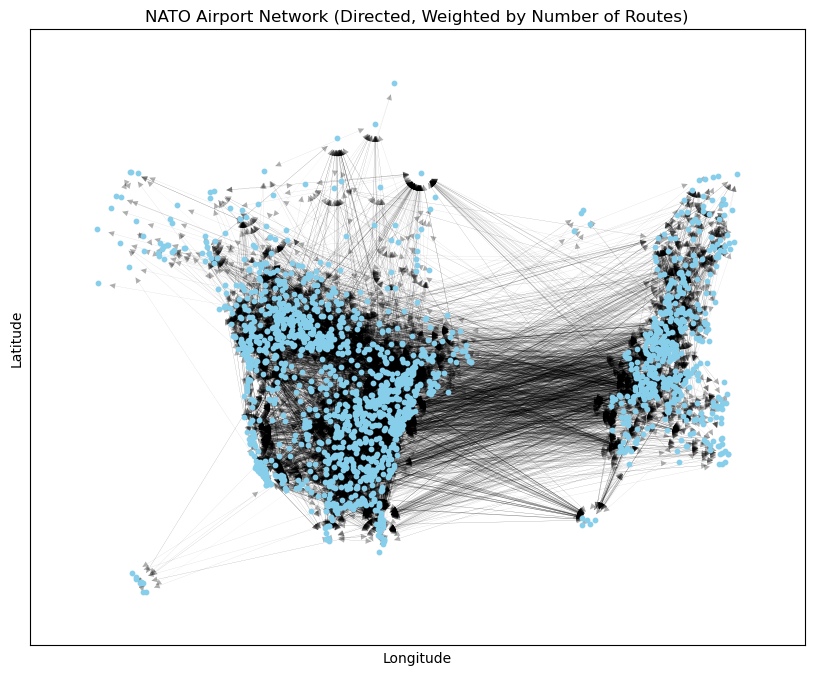

In [18]:
# =====================================================
# 📊 6. Visualization
# =====================================================
# Copy attributes
for n, d in G.nodes(data=True):
    if n in backboned_G:
        backboned_G.nodes[n].update(d)

plt.figure(figsize=(10, 8))
pos = {n: (d["lon"], d["lat"]) for n, d in backboned_G.nodes(data=True)}
edges = backboned_G.edges(data=True)
weights = [d["weight"] for _, _, d in edges]

nx.draw_networkx_nodes(backboned_G, pos, node_size=10, node_color="skyblue")
nx.draw_networkx_edges(backboned_G, pos, width=[w * 0.05 for w in weights], alpha=0.3)
plt.title("NATO Airport Network (Directed, Weighted by Number of Routes)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

/Users/joakimandersen/Downloads/enter/envs/py310/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/joakimandersen/Downloads/enter/envs/py310/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/joakimandersen/Downloads/enter/envs/py310/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/joakimandersen/Downloads/enter/envs/py310/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/joakimand

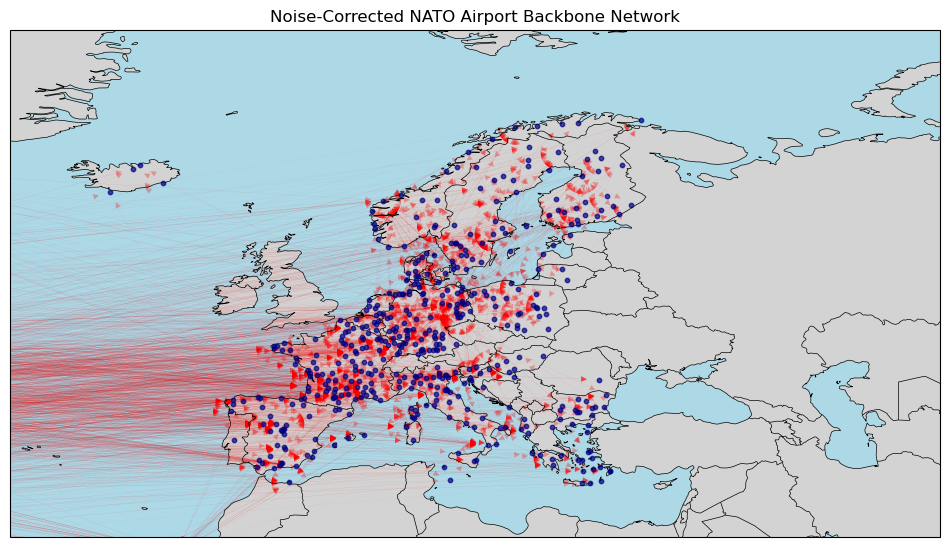

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import networkx as nx

# --- Copy coordinates from original ---
for n, d in G.nodes(data=True):
    if n in backboned_G:
        backboned_G.nodes[n].update(d)

# --- Create map ---
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-30, 60, 30, 75])  # roughly NATO region
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# --- Positions from coordinates ---
pos = {n: (d['lon'], d['lat']) for n, d in backboned_G.nodes(data=True)}
edges = backboned_G.edges(data=True)
weights = [d['weight'] for _, _, d in edges]

# --- Draw graph ---
nx.draw_networkx_edges(
    backboned_G, pos, ax=ax,
    width=[w * 0.02 for w in weights],
    alpha=0.3, edge_color='red'
)
nx.draw_networkx_nodes(
    backboned_G, pos, ax=ax,
    node_size=10, node_color='navy', alpha=0.7
)

plt.title("Noise-Corrected NATO Airport Backbone Network")
plt.show()


/Users/joakimandersen/Downloads/enter/envs/py310/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/joakimandersen/Downloads/enter/envs/py310/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


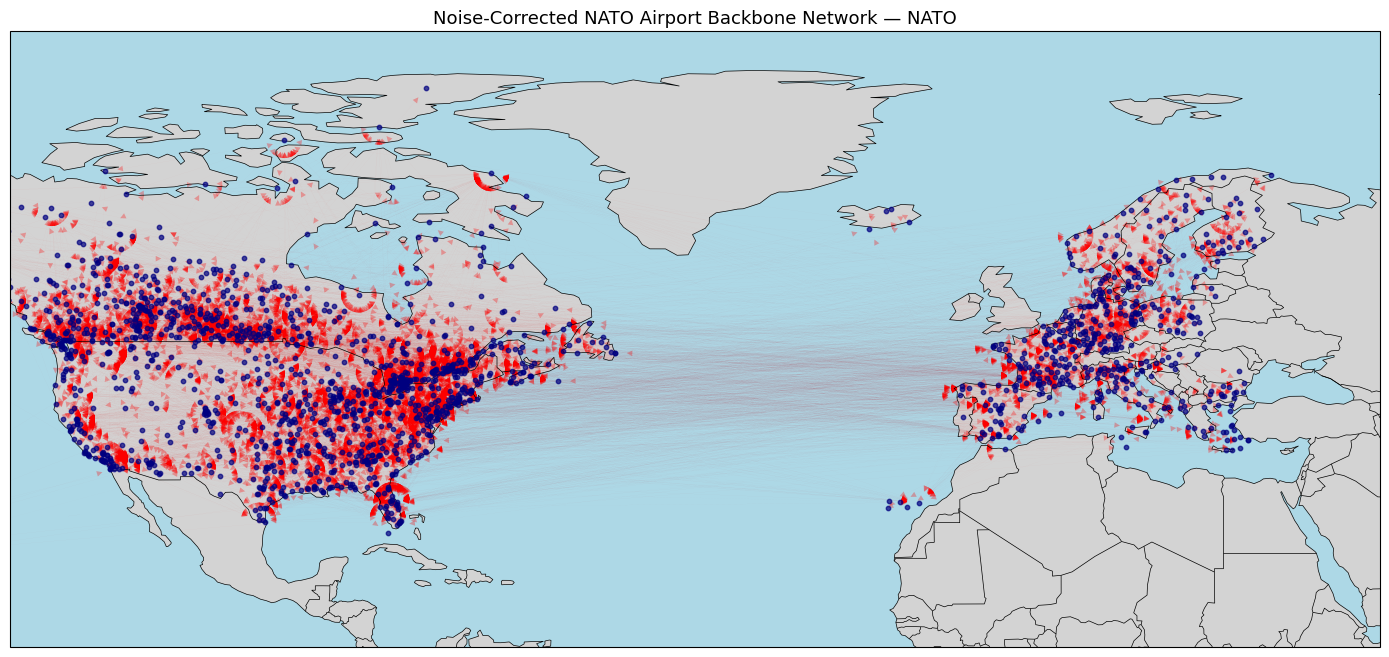

In [52]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import networkx as nx

# --- Copy coordinates from original ---
for n, d in G.nodes(data=True):
    if n in backboned_G:
        backboned_G.nodes[n].update(d)

# --- Create wider & slightly lower map ---
plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# ✅ Extended bounds: include US, Greenland, and more south (Mediterranean / Florida)
# [west, east, south, north]
ax.set_extent([-130, 45, 10, 70])

# --- Map features (same style) ---
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# --- Positions from coordinates ---
pos = {n: (d['lon'], d['lat']) for n, d in backboned_G.nodes(data=True)}
edges = backboned_G.edges(data=True)
weights = [d.get('weight', 1.0) for _, _, d in edges]

# --- Draw graph (unchanged style) ---
nx.draw_networkx_edges(
    backboned_G, pos, ax=ax,
    width=[w * 0.005 for w in weights],
    alpha=0.3, edge_color='red'
)
nx.draw_networkx_nodes(
    backboned_G, pos, ax=ax,
    node_size=10, node_color='navy', alpha=0.7

)

plt.title("Noise-Corrected NATO Airport Backbone Network — NATO", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
beta_in = 0.4      # infection probability for same-country neighbors
beta_out = 0.1     # infection probability for cross-country neighbors
gamma = 0.2        # recovery probability
timesteps = 20     # number of simulation steps
initial_infected = ["CPH"]  # starting airport(s)

In [53]:
import networkx as nx
import random

def SIS_simulation(G, beta_in=0.4, beta_out=0.1, gamma=0.2, timesteps=20, initial_infected=["CPH"]):
    # Initialize all nodes as susceptible
    nx.set_node_attributes(G, "S", "state")

    # Infect initial nodes
    for node in initial_infected:
        if node in G:
            G.nodes[node]["state"] = "I"

    infected_counts = []  # track # infected over time
    lcc_sizes = []        # track LCC size (weakly connected)

    for t in range(timesteps):
        new_states = {}

        for node in G.nodes():
            state = G.nodes[node]["state"]

            if state == "I":
                # Recovery step
                if random.random() < gamma:
                    new_states[node] = "S"
                else:
                    new_states[node] = "I"

                # Infection step
                for neighbor in G.neighbors(node):
                    if G.nodes[neighbor]["state"] == "S":
                        if G.nodes[node].get("country") == G.nodes[neighbor].get("country"):
                            p = beta_in
                        else:
                            p = beta_out
                        if random.random() < p:
                            new_states[neighbor] = "I"

            else:
                # Stay susceptible if not infected
                new_states.setdefault(node, "S")

        # Update all states
        nx.set_node_attributes(G, new_states, "state")

        # Count infected airports
        infected_count = sum(1 for n in G.nodes if G.nodes[n]["state"] == "I")
        infected_counts.append(infected_count)

        # Measure LCC size (weakly connected)
        largest_wcc_nodes = max(nx.weakly_connected_components(G), key=len)
        lcc_sizes.append(len(largest_wcc_nodes))

        print(f"Step {t+1}: Infected = {infected_count}, LCC size = {lcc_sizes[-1]}")

    return infected_counts, lcc_sizes


In [63]:
import random

# pick one random airport node from the backbone
initial_infected_random = [random.choice(list(backboned_G.nodes()))]
print("Random start:", initial_infected_random)


Random start: [7219]


In [72]:
infected_counts, lcc_sizes = SIS_simulation(
    backboned_G,
    beta_in=0.4,
    beta_out=0.1,
    gamma=0.5,
    timesteps=20,
    initial_infected=initial_infected_random
)


Step 1: Infected = 2, LCC size = 1728
Step 2: Infected = 2, LCC size = 1728
Step 3: Infected = 1, LCC size = 1728
Step 4: Infected = 1, LCC size = 1728
Step 5: Infected = 0, LCC size = 1728
Step 6: Infected = 0, LCC size = 1728
Step 7: Infected = 0, LCC size = 1728
Step 8: Infected = 0, LCC size = 1728
Step 9: Infected = 0, LCC size = 1728
Step 10: Infected = 0, LCC size = 1728
Step 11: Infected = 0, LCC size = 1728
Step 12: Infected = 0, LCC size = 1728
Step 13: Infected = 0, LCC size = 1728
Step 14: Infected = 0, LCC size = 1728
Step 15: Infected = 0, LCC size = 1728
Step 16: Infected = 0, LCC size = 1728
Step 17: Infected = 0, LCC size = 1728
Step 18: Infected = 0, LCC size = 1728
Step 19: Infected = 0, LCC size = 1728
Step 20: Infected = 0, LCC size = 1728


In [68]:
# sort airports by degree (descending)
deg_sorted = sorted(backboned_G.degree, key=lambda x: x[1], reverse=True)

# pick the top airport(s)
top_airports = [deg_sorted[0][0]]  # top hub
print("High-degree start:", top_airports)


High-degree start: [3682]


In [73]:
infected_counts_deg, lcc_sizes_deg = SIS_simulation(
    backboned_G,
    beta_in=0.4,
    beta_out=0.1,
    gamma=0.5,
    timesteps=20,
    initial_infected=top_airports
)


Step 1: Infected = 38, LCC size = 1728
Step 2: Infected = 69, LCC size = 1728
Step 3: Infected = 206, LCC size = 1728
Step 4: Infected = 258, LCC size = 1728
Step 5: Infected = 399, LCC size = 1728
Step 6: Infected = 621, LCC size = 1728
Step 7: Infected = 673, LCC size = 1728
Step 8: Infected = 714, LCC size = 1728
Step 9: Infected = 723, LCC size = 1728
Step 10: Infected = 742, LCC size = 1728
Step 11: Infected = 755, LCC size = 1728
Step 12: Infected = 754, LCC size = 1728
Step 13: Infected = 735, LCC size = 1728
Step 14: Infected = 728, LCC size = 1728
Step 15: Infected = 733, LCC size = 1728
Step 16: Infected = 746, LCC size = 1728
Step 17: Infected = 737, LCC size = 1728
Step 18: Infected = 764, LCC size = 1728
Step 19: Infected = 764, LCC size = 1728
Step 20: Infected = 729, LCC size = 1728


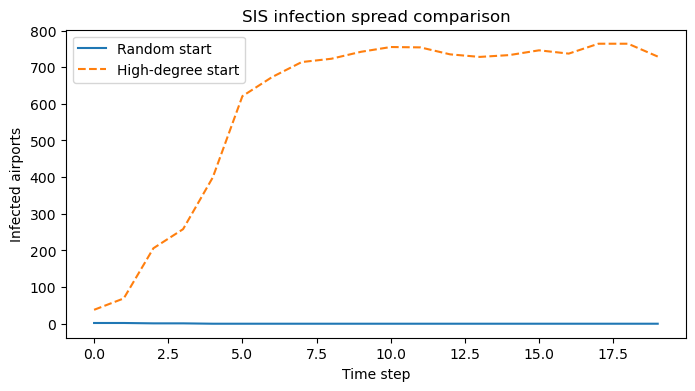

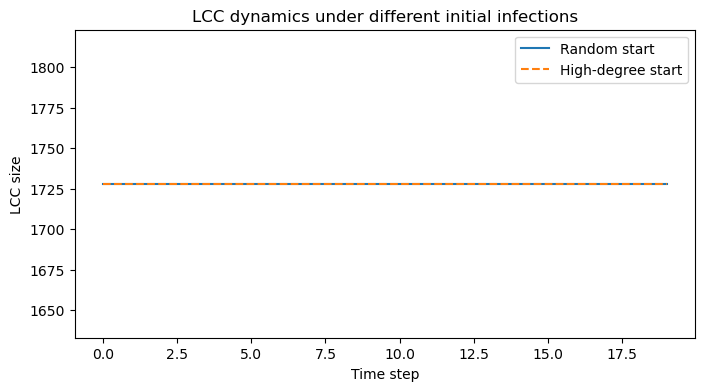

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(infected_counts, label="Random start")
plt.plot(infected_counts_deg, label="High-degree start", linestyle='--')
plt.xlabel("Time step")
plt.ylabel("Infected airports")
plt.title("SIS infection spread comparison")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(lcc_sizes, label="Random start")
plt.plot(lcc_sizes_deg, label="High-degree start", linestyle='--')
plt.xlabel("Time step")
plt.ylabel("LCC size")
plt.title("LCC dynamics under different initial infections")
plt.legend()
plt.show()
